In [1]:
import copy
import importlib
import io
import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from torch.profiler import ProfilerActivity, profile
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", message="torch.ao.quantization is deprecated")

if (Path.cwd() / "training").exists():
    ROOT = Path.cwd().resolve()
    TRAINING_DIR = ROOT / "training"
elif Path.cwd().name == "training":
    TRAINING_DIR = Path.cwd().resolve()
    ROOT = TRAINING_DIR.parent
else:
    raise RuntimeError("Run this notebook from the repository root or the training directory.")

sys.path.append(str(TRAINING_DIR))

CONFIG = {
    "seed": 42,
    "dataset_path": ROOT / "datasets" / "processed" / "huawei" / "huawei_5s_1000bins_features.npz",
    "checkpoint_path": TRAINING_DIR / "models" / "huawei_cnn_bimobilemamba_attention_best_0.9271.pt",
    "model_module": "cnn_bimobilemamba_attention",
    "model_builder": "build_cnn_bimobilemamba_attention_model",
    "model_kwargs": {
        "num_mamba_layers": 1,
        "mamba_dropout": 0.20,
        "stem_dropout": 0.15,
        "head_dropout": 0.35,
        "drop_path_rate": 0.15,
    },
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "batch_size": 64,
    "eval_device": "cpu",
    "nonstructured_pruning": {
        "target_sparsity": 0.30,
        "steps": 3,
        "gradient_alpha": 0.50,
        "calibration_batches": 3,
        "stability_margin_tolerance": 1e-4,
        "stability_restore_fraction": 0.02,
        "stability_restore_passes": 3,
    },
    "a_guided_state_pruning": {
        "state_pruning_ratio": 0.25,
        "calibration_batches": 3,
    },
    "latency_warmup_batches": 2,
    "latency_timed_batches": 10,
    "log1p_features": [
        "pkt_count",
        "pkt_len_mean",
        "pkt_len_std",
        "last_pkt_global_iat",
        "uplink_pkt_len_sum",
        "downlink_pkt_len_sum",
        "uplink_pkt_count",
        "downlink_pkt_count",
    ],
}

if not np.isclose(CONFIG["train_ratio"] + CONFIG["val_ratio"] + CONFIG["test_ratio"], 1.0):
    raise ValueError("train_ratio + val_ratio + test_ratio must equal 1.0")


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(int(CONFIG["seed"]))
eval_device = torch.device(CONFIG["eval_device"])
print("Repository root:", ROOT)
print("Training dir:", TRAINING_DIR)
print("Dataset path:", CONFIG["dataset_path"])
print("Checkpoint path:", CONFIG["checkpoint_path"])
print("Evaluation device:", eval_device)
print("Non-structured pruning config:", CONFIG["nonstructured_pruning"])
print("A-guided state pruning config:", CONFIG["a_guided_state_pruning"])


Repository root: /home/ronghanj/dev/network-traffic-classification
Training dir: /home/ronghanj/dev/network-traffic-classification/training
Dataset path: /home/ronghanj/dev/network-traffic-classification/datasets/processed/huawei/huawei_5s_1000bins_features.npz
Checkpoint path: /home/ronghanj/dev/network-traffic-classification/training/models/huawei_cnn_bimobilemamba_attention_best_0.9271.pt
Evaluation device: cpu
Non-structured pruning config: {'target_sparsity': 0.3, 'steps': 3, 'gradient_alpha': 0.5, 'calibration_batches': 3, 'stability_margin_tolerance': 0.0001, 'stability_restore_fraction': 0.02, 'stability_restore_passes': 3}
A-guided state pruning config: {'state_pruning_ratio': 0.25, 'calibration_batches': 3}


In [2]:
data_path = Path(CONFIG["dataset_path"])
if not data_path.exists():
    raise FileNotFoundError(f"Cannot find dataset file: {data_path}")

data = np.load(data_path, allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(np.int64)
classes = data["classes"].astype(str) if "classes" in data.files else np.unique(y).astype(str)
feature_names = (
    data["feature_names"].astype(str)
    if "feature_names" in data.files
    else np.array([f"feature_{i}" for i in range(X.shape[-1])], dtype=str)
)

test_ratio = float(CONFIG["test_ratio"])
val_ratio = float(CONFIG["val_ratio"])
remaining_ratio = 1.0 - test_ratio
val_ratio_within_temp = val_ratio / remaining_ratio

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=test_ratio,
    random_state=int(CONFIG["seed"]),
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_ratio_within_temp,
    random_state=int(CONFIG["seed"]),
    stratify=y_temp,
)

feature_name_to_idx = {name: idx for idx, name in enumerate(feature_names.tolist())}
missing_log1p_features = [name for name in CONFIG["log1p_features"] if name not in feature_name_to_idx]
if missing_log1p_features:
    raise ValueError(f"Unknown log1p features: {missing_log1p_features}")

log1p_feature_indices = [feature_name_to_idx[name] for name in CONFIG["log1p_features"]]
num_features = X_train.shape[-1]


def apply_log1p_transform(x3d, feature_indices):
    transformed = x3d.copy()
    if feature_indices:
        transformed[:, :, feature_indices] = np.log1p(
            np.clip(transformed[:, :, feature_indices], a_min=0.0, a_max=None)
        )
    return transformed.astype(np.float32)


X_train_log = apply_log1p_transform(X_train, log1p_feature_indices)
X_val_log = apply_log1p_transform(X_val, log1p_feature_indices)
X_test_log = apply_log1p_transform(X_test, log1p_feature_indices)

scaler = RobustScaler(with_centering=True, with_scaling=True)
scaler.fit(X_train_log.reshape(-1, num_features))


def apply_scaler(x3d):
    x2d = scaler.transform(x3d.reshape(-1, num_features))
    return x2d.reshape(x3d.shape).astype(np.float32)


X_train_scaled = apply_scaler(X_train_log)
X_val_scaled = apply_scaler(X_val_log)
X_test_scaled = apply_scaler(X_test_log)

val_dataset = TensorDataset(torch.from_numpy(X_val_scaled).float(), torch.from_numpy(y_val).long())
test_dataset = TensorDataset(torch.from_numpy(X_test_scaled).float(), torch.from_numpy(y_test).long())
calibration_loader = DataLoader(val_dataset, batch_size=int(CONFIG["batch_size"]), shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=int(CONFIG["batch_size"]), shuffle=False)

print("X shape:", X.shape)
print("Train / Val / Test:", X_train.shape, X_val.shape, X_test.shape)
print("Classes:", classes.tolist())
print("Applied log1p to:", CONFIG["log1p_features"])
print("Calibration batches:", len(calibration_loader))
print("Test batches:", len(test_loader))


X shape: (3200, 1000, 10)
Train / Val / Test: (2239, 1000, 10) (481, 1000, 10) (480, 1000, 10)
Classes: ['cloud_game', 'live', 'meeting', 'message', 'openlive', 'phone_game', 'short_video', 'video']
Applied log1p to: ['pkt_count', 'pkt_len_mean', 'pkt_len_std', 'last_pkt_global_iat', 'uplink_pkt_len_sum', 'downlink_pkt_len_sum', 'uplink_pkt_count', 'downlink_pkt_count']
Calibration batches: 8
Test batches: 8


In [3]:
model_module = importlib.import_module(CONFIG["model_module"])
model_builder = getattr(model_module, CONFIG["model_builder"])
criterion = nn.CrossEntropyLoss()
quantize_dynamic_fn = getattr(torch.quantization, "quantize_dynamic")


def load_checkpoint_state_dict(checkpoint_path, map_location="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=map_location)
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]
    return checkpoint


def build_model_from_checkpoint():
    model = model_builder(
        input_shape=X_train_scaled.shape[1:],
        num_classes=len(np.unique(y)),
        **CONFIG["model_kwargs"],
    )
    state_dict = load_checkpoint_state_dict(CONFIG["checkpoint_path"], map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    return model


def clone_linear(linear, in_features=None, out_features=None, weight=None, bias=None):
    new_linear = nn.Linear(
        in_features if in_features is not None else linear.in_features,
        out_features if out_features is not None else linear.out_features,
        bias=linear.bias is not None,
    )
    new_linear.weight.data.copy_(weight if weight is not None else linear.weight.data)
    if linear.bias is not None:
        new_linear.bias.data.copy_(bias if bias is not None else linear.bias.data)
    return new_linear


def count_parameters(model):
    return int(sum(param.numel() for param in model.parameters()))


def count_nonzero_parameters(model):
    return int(sum(torch.count_nonzero(param).item() for param in model.parameters()))


def profile_model_complexity(model, input_shape):
    profile_model = copy.deepcopy(model).cpu().eval()
    example_input = torch.randn(1, *input_shape, dtype=torch.float32)
    try:
        with profile(
            activities=[ProfilerActivity.CPU],
            with_flops=True,
            record_shapes=False,
            acc_events=True,
        ) as prof:
            with torch.no_grad():
                _ = profile_model(example_input)
        total_flops = float(sum(getattr(event, "flops", 0) for event in prof.key_averages()))
        if total_flops <= 0:
            return float("nan"), float("nan")
        return total_flops, total_flops / 2.0
    except Exception:
        return float("nan"), float("nan")


def evaluate_model(model, loader, device):
    model = model.to(device)
    model.eval()
    losses = []
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item() * yb.size(0))
            y_true.append(yb.cpu().numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    avg_loss = float(np.sum(losses) / len(y_true))
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro"))
    report = classification_report(y_true, y_pred, target_names=classes.tolist(), digits=4, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "loss": avg_loss,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_true": y_true,
        "y_pred": y_pred,
        "report": report,
        "confusion_matrix": cm,
    }


def measure_latency_ms(model, loader, device, warmup_batches=2, timed_batches=10):
    model = model.to(device)
    model.eval()
    timings = []

    with torch.no_grad():
        for batch_idx, (xb, _) in enumerate(loader):
            xb = xb.to(device)
            if device.type == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(xb)
            if device.type == "cuda":
                torch.cuda.synchronize()
            elapsed_ms = (time.perf_counter() - start) * 1000.0
            if batch_idx >= warmup_batches:
                timings.append(elapsed_ms)
            if len(timings) >= timed_batches:
                break

    if not timings:
        return float("nan")
    return float(np.mean(timings))


def estimate_state_dict_size_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return float(buffer.tell() / (1024 ** 2))


def quantize_dynamic_linear_layers(model):
    model = model.cpu().eval()
    return quantize_dynamic_fn(model, {nn.Linear}, dtype=torch.qint8)


def get_nonstructured_prunable_param_map(model):
    prunable = {}
    excluded_tokens = ("norm", ".bn", "layer_scale")
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(token in name for token in excluded_tokens):
            continue
        if name.endswith(("weight", "bias", "A_log", "D")):
            prunable[name] = param
    return prunable


def initialize_masks(param_map):
    return {name: torch.ones_like(param, dtype=torch.float32) for name, param in param_map.items()}


def apply_parameter_masks(model, masks):
    param_map = dict(model.named_parameters())
    for name, mask in masks.items():
        if name in param_map:
            param_map[name].data.mul_(mask.to(param_map[name].device, dtype=param_map[name].dtype))


def compute_cubic_target_sparsity(step, total_steps, final_sparsity):
    progress = step / total_steps
    return float(final_sparsity * (1.0 - (1.0 - progress) ** 3))


def collect_gradient_importance_scores(model, loader, masks, alpha, num_batches):
    model = model.cpu().eval()
    param_map = get_nonstructured_prunable_param_map(model)
    grad_accumulator = {name: torch.zeros_like(param, dtype=torch.float32) for name, param in param_map.items()}
    used_batches = 0

    for xb, yb in loader:
        if used_batches >= num_batches:
            break
        xb = xb.cpu()
        yb = yb.cpu()
        model.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        for name, param in param_map.items():
            if param.grad is None:
                continue
            grad_accumulator[name] += param.grad.detach().abs().to(torch.float32)
        used_batches += 1

    divisor = max(1, used_batches)
    score_map = {}
    for name, param in param_map.items():
        grad_term = (grad_accumulator[name] / divisor).pow(alpha)
        score = param.detach().abs().to(torch.float32) * grad_term
        score_map[name] = score * masks[name]
    return score_map


def build_global_mask_from_scores(score_map, current_masks, target_sparsity):
    total_params = sum(mask.numel() for mask in current_masks.values())
    keep_total = max(1, int(round(total_params * (1.0 - target_sparsity))))
    flat_chunks = []
    meta = []

    for name, score in score_map.items():
        flat_score = score.reshape(-1)
        eligible_idx = current_masks[name].reshape(-1).bool().nonzero(as_tuple=False).squeeze(-1)
        if eligible_idx.numel() == 0:
            meta.append((name, eligible_idx, 0))
            continue
        flat_chunks.append(flat_score[eligible_idx])
        meta.append((name, eligible_idx, eligible_idx.numel()))

    all_scores = torch.cat(flat_chunks) if flat_chunks else torch.empty(0, dtype=torch.float32)
    if all_scores.numel() == 0:
        return {name: mask.clone() for name, mask in current_masks.items()}

    keep_total = min(keep_total, all_scores.numel())
    topk_indices = torch.topk(all_scores, k=keep_total, largest=True).indices
    new_masks = {name: torch.zeros_like(mask) for name, mask in current_masks.items()}

    offset = 0
    for name, eligible_idx, chunk_size in meta:
        if chunk_size == 0:
            continue
        local_selector = (topk_indices >= offset) & (topk_indices < offset + chunk_size)
        selected_local = topk_indices[local_selector] - offset
        flat_mask = new_masks[name].reshape(-1)
        flat_mask[eligible_idx[selected_local]] = 1.0
        offset += chunk_size
    return new_masks


def estimate_ssm_stability_margins(model, loader, num_batches):
    model = model.cpu().eval()
    captured_inputs = {}
    ssm_modules = {}
    hooks = []

    def make_hook(module_name):
        def hook(module, inputs):
            del module
            captured_inputs[module_name].append(inputs[0].detach().cpu())
        return hook

    for module_name, module in model.named_modules():
        if isinstance(module, model_module.MobileMambaSSMLayer):
            captured_inputs[module_name] = []
            ssm_modules[module_name] = module
            hooks.append(module.register_forward_pre_hook(make_hook(module_name)))

    with torch.no_grad():
        for batch_idx, (xb, _) in enumerate(loader):
            if batch_idx >= num_batches:
                break
            _ = model(xb.cpu())

    for hook in hooks:
        hook.remove()

    stability_margins = {}
    for module_name, module in ssm_modules.items():
        if not captured_inputs[module_name]:
            stability_margins[module_name] = float("nan")
            continue

        max_discrete_pole = 0.0
        for x in captured_inputs[module_name]:
            combined = module.in_proj(x)
            u, _ = torch.chunk(combined, 2, dim=-1)
            u = module.conv1d(u.transpose(1, 2)).transpose(1, 2)
            u = F.silu(u)
            x_dbl = module.x_proj(u)
            delta_pre, _, _ = torch.split(x_dbl, [module.d_inner, module.d_state, module.d_state], dim=-1)
            delta = F.softplus(module.dt_proj(delta_pre))
            a = -torch.exp(module.A_log)
            d_a = torch.exp(delta.unsqueeze(-1) * a.unsqueeze(0))
            max_discrete_pole = max(max_discrete_pole, float(d_a.max().item()))
        stability_margins[module_name] = 1.0 - max_discrete_pole
    return stability_margins


def preserve_ssm_stability(model, masks, score_map, loader, pruning_config):
    tolerance = float(pruning_config["stability_margin_tolerance"])
    restore_fraction = float(pruning_config["stability_restore_fraction"])
    restore_passes = int(pruning_config["stability_restore_passes"])
    protected_names = [
        name
        for name in masks
        if name.endswith("A_log") or name.endswith("dt_proj.weight") or name.endswith("dt_proj.bias")
    ]

    def margins_are_safe(margins):
        return all((not np.isfinite(margin)) or (margin > tolerance) for margin in margins.values())

    tentative_model = copy.deepcopy(model).cpu().eval()
    apply_parameter_masks(tentative_model, masks)
    stability_margins = estimate_ssm_stability_margins(
        tentative_model,
        loader,
        int(pruning_config["calibration_batches"]),
    )
    if margins_are_safe(stability_margins):
        return masks, stability_margins

    for _ in range(restore_passes):
        for name in protected_names:
            flat_mask = masks[name].reshape(-1)
            masked_idx = (flat_mask == 0).nonzero(as_tuple=False).squeeze(-1)
            if masked_idx.numel() == 0:
                continue
            restore_k = max(1, int(np.ceil(masked_idx.numel() * restore_fraction)))
            restore_k = min(restore_k, masked_idx.numel())
            restore_scores = score_map[name].reshape(-1)[masked_idx]
            selected = masked_idx[torch.topk(restore_scores, k=restore_k, largest=True).indices]
            flat_mask[selected] = 1.0

        tentative_model = copy.deepcopy(model).cpu().eval()
        apply_parameter_masks(tentative_model, masks)
        stability_margins = estimate_ssm_stability_margins(
            tentative_model,
            loader,
            int(pruning_config["calibration_batches"]),
        )
        if margins_are_safe(stability_margins):
            break
    return masks, stability_margins


def gradient_aware_nonstructured_prune_model(model, loader, pruning_config):
    pruned_model = copy.deepcopy(model).cpu().eval()
    param_map = get_nonstructured_prunable_param_map(pruned_model)
    masks = initialize_masks(param_map)
    stability_margins = {}

    for step in range(1, int(pruning_config["steps"]) + 1):
        apply_parameter_masks(pruned_model, masks)
        score_map = collect_gradient_importance_scores(
            pruned_model,
            loader,
            masks,
            alpha=float(pruning_config["gradient_alpha"]),
            num_batches=int(pruning_config["calibration_batches"]),
        )
        target_sparsity = compute_cubic_target_sparsity(
            step,
            int(pruning_config["steps"]),
            float(pruning_config["target_sparsity"]),
        )
        masks = build_global_mask_from_scores(score_map, masks, target_sparsity)
        masks, stability_margins = preserve_ssm_stability(pruned_model, masks, score_map, loader, pruning_config)
        apply_parameter_masks(pruned_model, masks)

    pruned_model.eval()
    return pruned_model, masks, stability_margins


def collect_state_activity_scores(model, loader, num_batches):
    model = model.cpu().eval()
    captured_inputs = {}
    ssm_modules = {}
    hooks = []

    def make_hook(module_name):
        def hook(module, inputs):
            del module
            captured_inputs[module_name].append(inputs[0].detach().cpu())
        return hook

    for module_name, module in model.named_modules():
        if isinstance(module, model_module.MobileMambaSSMLayer):
            captured_inputs[module_name] = []
            ssm_modules[module_name] = module
            hooks.append(module.register_forward_pre_hook(make_hook(module_name)))

    with torch.no_grad():
        for batch_idx, (xb, _) in enumerate(loader):
            if batch_idx >= num_batches:
                break
            _ = model(xb.cpu())

    for hook in hooks:
        hook.remove()

    activity_scores = {}
    for module_name, module in ssm_modules.items():
        state_activity = torch.zeros(module.d_state, dtype=torch.float32)
        for x in captured_inputs[module_name]:
            combined = module.in_proj(x)
            u, _ = torch.chunk(combined, 2, dim=-1)
            u = module.conv1d(u.transpose(1, 2)).transpose(1, 2)
            u = F.silu(u)
            x_dbl = module.x_proj(u)
            delta_pre, _, _ = torch.split(x_dbl, [module.d_inner, module.d_state, module.d_state], dim=-1)
            delta = F.softplus(module.dt_proj(delta_pre))
            a = -torch.exp(module.A_log)
            discrete_decay = torch.exp(delta.unsqueeze(-1) * a.unsqueeze(0))
            state_activity += (1.0 - discrete_decay).mean(dim=(0, 1, 2)).to(torch.float32)
        divisor = max(1, len(captured_inputs[module_name]))
        activity_scores[module_name] = state_activity / divisor
    return activity_scores


def prune_ssm_state_channels(module, keep_idx):
    keep_idx = keep_idx.to(dtype=torch.long)
    base_idx = torch.arange(module.d_inner, dtype=torch.long)
    b_idx = module.d_inner + keep_idx
    c_idx = module.d_inner + module.d_state + keep_idx
    selected_rows = torch.cat([base_idx, b_idx, c_idx])
    module.x_proj = clone_linear(
        module.x_proj,
        out_features=selected_rows.numel(),
        weight=module.x_proj.weight.data[selected_rows].clone(),
        bias=module.x_proj.bias.data[selected_rows].clone() if module.x_proj.bias is not None else None,
    )
    module.A_log = nn.Parameter(module.A_log.data[:, keep_idx].clone())
    module.d_state = int(keep_idx.numel())
    return module


def a_guided_state_prune_model(model, loader, pruning_config):
    pruned_model = copy.deepcopy(model).cpu().eval()
    activity_scores = collect_state_activity_scores(
        pruned_model,
        loader,
        int(pruning_config["calibration_batches"]),
    )

    for module_name, module in list(pruned_model.named_modules()):
        if not isinstance(module, model_module.MobileMambaSSMLayer):
            continue
        scores = activity_scores[module_name]
        keep_states = max(1, int(round(module.d_state * (1.0 - float(pruning_config["state_pruning_ratio"])))))
        keep_idx = torch.topk(scores, k=keep_states, largest=True).indices.sort().values
        prune_ssm_state_channels(module, keep_idx)
    return pruned_model, activity_scores


def summarize_structure(model):
    forward_state_dims = []
    backward_state_dims = []
    for block in model.mamba_blocks:
        forward_state_dims.append(block.ssm.forward_mamba.d_state)
        backward_state_dims.append(block.ssm.backward_mamba.d_state)
    return {
        "forward_state_dims": forward_state_dims,
        "backward_state_dims": backward_state_dims,
        "ffn_hidden": [block.ffn[0].out_features for block in model.mamba_blocks],
        "classifier_hidden": model.classifier[1].out_features,
    }


def evaluate_variant(name, model, reference_model, baseline_param_count, extra_metrics=None):
    metrics = evaluate_model(model, test_loader, eval_device)
    total_params = count_parameters(reference_model)
    nonzero_params = count_nonzero_parameters(reference_model)
    flops, macs = profile_model_complexity(reference_model, X_train_scaled.shape[1:])
    metrics["param_count"] = total_params
    metrics["nonzero_params"] = nonzero_params
    metrics["param_reduction_pct"] = float((1.0 - (total_params / baseline_param_count)) * 100.0)
    metrics["weight_sparsity_pct"] = float((1.0 - (nonzero_params / total_params)) * 100.0) if total_params else 0.0
    metrics["flops"] = flops
    metrics["macs"] = macs
    metrics["state_dict_mb"] = estimate_state_dict_size_mb(model)
    metrics["latency_ms"] = measure_latency_ms(
        model,
        test_loader,
        eval_device,
        warmup_batches=int(CONFIG["latency_warmup_batches"]),
        timed_batches=int(CONFIG["latency_timed_batches"]),
    )
    metrics["structure"] = summarize_structure(reference_model)
    metrics["variant"] = name
    if extra_metrics:
        metrics.update(extra_metrics)
    return metrics


In [4]:
baseline_model = build_model_from_checkpoint()
quantized_model = quantize_dynamic_linear_layers(copy.deepcopy(baseline_model))

gradaware_unstructured_model, gradaware_masks, gradaware_stability = gradient_aware_nonstructured_prune_model(
    baseline_model,
    calibration_loader,
    CONFIG["nonstructured_pruning"],
)
gradaware_unstructured_quantized_model = quantize_dynamic_linear_layers(copy.deepcopy(gradaware_unstructured_model))

a_guided_state_pruned_model, a_guided_activity = a_guided_state_prune_model(
    baseline_model,
    calibration_loader,
    CONFIG["a_guided_state_pruning"],
)
a_guided_state_pruned_quantized_model = quantize_dynamic_linear_layers(copy.deepcopy(a_guided_state_pruned_model))

baseline_param_count = count_parameters(baseline_model)
gradaware_min_margin = min(gradaware_stability.values()) if gradaware_stability else float("nan")

a_guided_activity_summary = {
    module_name: scores.detach().cpu().numpy().round(4).tolist()
    for module_name, scores in a_guided_activity.items()
}

variant_specs = [
    ("baseline_fp32", baseline_model, baseline_model, {"stability_margin_min": float("nan")} ),
    ("quantized_int8", quantized_model, baseline_model, {"stability_margin_min": float("nan")} ),
    (
        "gradaware_unstructured_fp32",
        gradaware_unstructured_model,
        gradaware_unstructured_model,
        {"stability_margin_min": gradaware_min_margin},
    ),
    (
        "gradaware_unstructured_quantized_int8",
        gradaware_unstructured_quantized_model,
        gradaware_unstructured_model,
        {"stability_margin_min": gradaware_min_margin},
    ),
    (
        "a_guided_state_pruned_fp32",
        a_guided_state_pruned_model,
        a_guided_state_pruned_model,
        {"stability_margin_min": float("nan")},
    ),
    (
        "a_guided_state_pruned_quantized_int8",
        a_guided_state_pruned_quantized_model,
        a_guided_state_pruned_model,
        {"stability_margin_min": float("nan")},
    ),
]

variant_results = {
    name: evaluate_variant(name, eval_model, reference_model, baseline_param_count, extra_metrics)
    for name, eval_model, reference_model, extra_metrics in variant_specs
}

comparison_df = pd.DataFrame(
    [
        {
            "variant": result["variant"],
            "loss": result["loss"],
            "accuracy": result["accuracy"],
            "macro_f1": result["macro_f1"],
            "param_count": result["param_count"],
            "nonzero_params": result["nonzero_params"],
            "param_reduction_pct": result["param_reduction_pct"],
            "weight_sparsity_pct": result["weight_sparsity_pct"],
            "flops": result["flops"],
            "macs": result["macs"],
            "state_dict_mb": result["state_dict_mb"],
            "latency_ms": result["latency_ms"],
            "forward_state_dims": result["structure"]["forward_state_dims"],
            "backward_state_dims": result["structure"]["backward_state_dims"],
            "ffn_hidden": result["structure"]["ffn_hidden"],
            "classifier_hidden": result["structure"]["classifier_hidden"],
            "stability_margin_min": result["stability_margin_min"],
        }
        for result in variant_results.values()
    ]
).sort_values(["accuracy", "macro_f1"], ascending=False)

comparison_df


,variant,loss,accuracy,macro_f1,param_count,nonzero_params,param_reduction_pct,weight_sparsity_pct,flops,macs,state_dict_mb,latency_ms,forward_state_dims,backward_state_dims,ffn_hidden,classifier_hidden,stability_margin_min
0,baseline_fp32,0.269148,0.927083,0.927132,82217,82217,0.000000,0.000000,33117888.0,16558944.0,0.334579,206.082859,[16],[16],[128],96,NaN
2,gradaware_unstructured_fp32,0.272140,0.927083,0.927107,82217,58010,0.000000,29.442816,33117888.0,16558944.0,0.334579,169.797083,[16],[16],[128],96,0.000017
4,a_guided_state_pruned_fp32,0.274630,0.925000,0.925108,80681,80681,1.868227,0.000000,32093888.0,16046944.0,0.328719,197.827635,[12],[12],[128],96,NaN
3,gradaware_unstructured_quantized_int8,0.276337,0.918750,0.918644,82217,58010,0.000000,29.442816,33117888.0,16558944.0,0.149196,177.512479,[16],[16],[128],96,0.000017
1,quantized_int8,0.273074,0.918750,0.918618,82217,82217,0.000000,0.000000,33117888.0,16558944.0,0.149196,178.073527,[16],[16],[128],96,NaN
5,a_guided_state_pruned_quantized_int8,0.286839,0.916667,0.916524,80681,80681,1.868227,0.000000,32093888.0,16046944.0,0.146266,222.732463,[12],[12],[128],96,NaN


A-guided state activity summary:
mamba_blocks.0.ssm.forward_mamba [0.6686000227928162, 0.8324999809265137, 0.9002000093460083, 0.9348999857902527, 0.953499972820282, 0.9653000235557556, 0.9722999930381775, 0.9778000116348267, 0.9822999835014343, 0.9851999878883362, 0.9878000020980835, 0.9890999794006348, 0.9907000064849854, 0.991599977016449, 0.9926999807357788, 0.9940000176429749]
mamba_blocks.0.ssm.backward_mamba [0.6200000047683716, 0.7955999970436096, 0.8733999729156494, 0.9083999991416931, 0.9337999820709229, 0.9473999738693237, 0.954800009727478, 0.9621000289916992, 0.9681000113487244, 0.9706000089645386, 0.9739000201225281, 0.9775000214576721, 0.9790999889373779, 0.9794999957084656, 0.9807000160217285, 0.9825999736785889]

===== baseline_fp32 =====
loss=0.2691 accuracy=0.9271 macro_f1=0.9271
params=82,217 nonzero=82,217 param_reduction=0.00% weight_sparsity=0.00% FLOPs=33,117,888 MACs=16,558,944 state_dict=0.335 MB latency=206.08 ms
state_dims(fwd/bwd)=[16]/[16] ffn_hidden=[128]

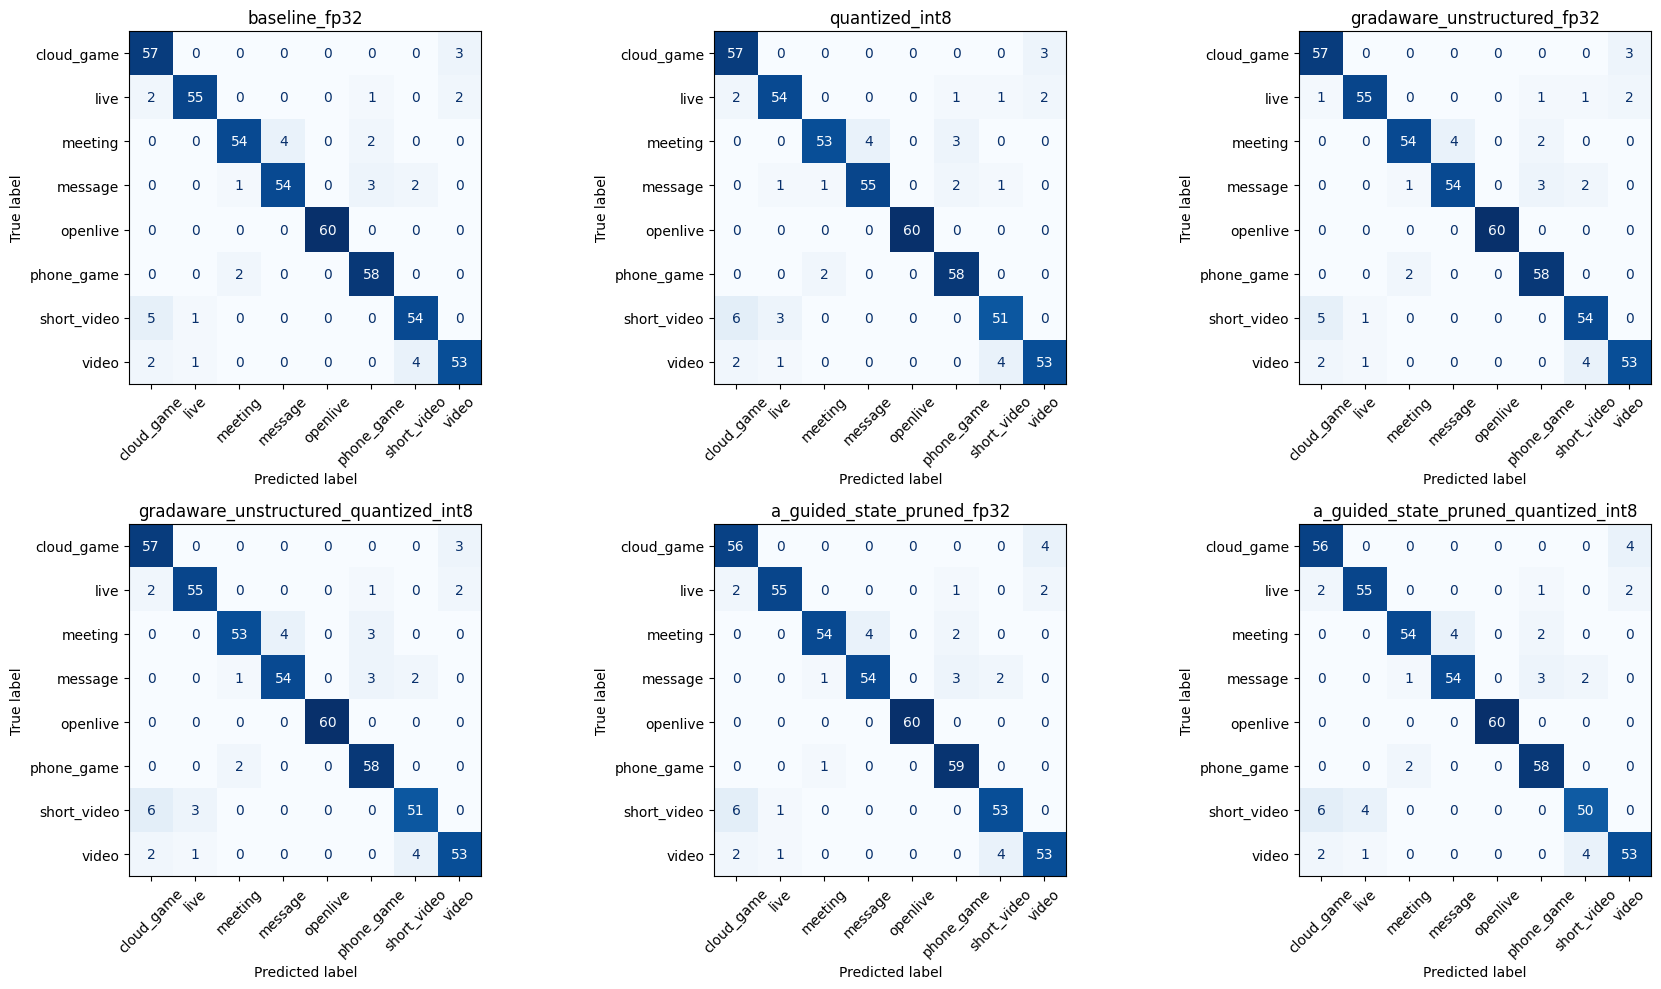

In [5]:
def format_count(value):
    return "unavailable" if not np.isfinite(value) else f"{value:,.0f}"


def format_float(value, digits=4):
    return "unavailable" if not np.isfinite(value) else f"{value:.{digits}f}"


print("A-guided state activity summary:")
for module_name, scores in a_guided_activity_summary.items():
    print(module_name, scores)
print()

for name, result in variant_results.items():
    structure = result["structure"]
    print(f"===== {name} =====")
    print(f"loss={result['loss']:.4f} accuracy={result['accuracy']:.4f} macro_f1={result['macro_f1']:.4f}")
    print(
        f"params={result['param_count']:,} nonzero={result['nonzero_params']:,} "
        f"param_reduction={result['param_reduction_pct']:.2f}% "
        f"weight_sparsity={result['weight_sparsity_pct']:.2f}% "
        f"FLOPs={format_count(result['flops'])} "
        f"MACs={format_count(result['macs'])} "
        f"state_dict={result['state_dict_mb']:.3f} MB "
        f"latency={result['latency_ms']:.2f} ms"
    )
    print(
        f"state_dims(fwd/bwd)={structure['forward_state_dims']}/{structure['backward_state_dims']} "
        f"ffn_hidden={structure['ffn_hidden']} classifier_hidden={structure['classifier_hidden']} "
        f"stability_margin_min={format_float(result['stability_margin_min'])}"
    )
    print(pd.DataFrame(result['report']).transpose().round(4))
    print()

variant_items = list(variant_results.items())
n_cols = 3
n_rows = int(np.ceil(len(variant_items) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (name, result) in zip(axes, variant_items):
    disp = ConfusionMatrixDisplay(confusion_matrix=result['confusion_matrix'], display_labels=classes.tolist())
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
    ax.set_title(name)

for ax in axes[len(variant_items):]:
    ax.axis("off")

fig.tight_layout()
plt.show()
